In [ ]:
import numpy as np
import random
from typing import Callable, Union, Type, List
from typeguard import check_type
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

In [242]:
class Neuron:
    def __init__(self):
        self.weights = None

    def compile(self, inp_features:int):
        self.weights = np.array([np.random.standard_normal(inp_features)]).reshape(1, inp_features) * np.sqrt(2./inp_features) #weights shape: 1 x inp_features
        return self.weights

In [243]:
class Layer:
    def __init__(self, name:str):
        self.name = name

    def __str__(self):
        return f"Layer : {self.name}"

    def forward(self, inp:np.array):
        pass

    def backward(self, inp:np.array, prev_grad:np.array, lr:float=0.01):
        pass


class LinearLayer(Layer):
    def __init__(self, name, inp_features:int, out_features:int):
        self.name = name
        super().__init__(name)  
        self.neurons = [Neuron() for _ in range(out_features)]
        self.weights = np.array([neuron.compile(inp_features) for neuron in self.neurons]).squeeze() #weights shape : out_features x inp_features
        self.bias = np.array(np.random.randn(out_features)).reshape(1, out_features)
        print(f"Linear layer weights shape: {self.weights.shape}")
        self.inp = None
    
    def __str__(self):
        return f"Linear Layer : {self.name}, neurons:{len(self.neurons)}"
    
    def __repr__(self):
        return f"Linear Layer : {self.name}, neurons:{len(self.neurons)}"

    def forward(self, inp:np.array):#inp shape :  n x inp_features
        self.inp = inp
        self.temp_var = inp @ self.weights.T + self.bias # Z = X @ W.T
        return self.temp_var # z shape : n x out_features
    
    def backward(self, prev_grad:np.array, lr:float=0.01): # considering pred_grad shape : n x out_features
        dzdw = self.inp.T # i x inp_features
        dzdb = np.sum(prev_grad, axis=0, keepdims=True)
        self.weights -= lr*(dzdw @ prev_grad).T / self.inp.shape[0] # inp_features x out_features
        self.bias -= lr*dzdb / self.inp.shape[0]
        dzdx = prev_grad @ self.weights #1 x inp_features
        return dzdx.T


class Sigmoid(Layer):
    def __init__(self, name):
        self.name = name
        self.inp = None
    
    def __str__(self):
        return f"Sigmoid Layer : {self.name}"
    
    def __repr__(self):
        return f"Sigmoid Layer : {self.name}"
    
    def forward(self, inp:np.array): # inp shape: n x out_features
        self.inp = np.clip(inp, -200, 200)
        self.temp_var = 1.0/(1.0+np.exp(-inp)) # n x out_features
        return self.temp_var
    
    def backward(self, prev_grad:np.array, lr=0.01):#prev_grad : out_features x 1
        dsig = self.temp_var * (1-self.temp_var) #dsig shape : n x out_features
        return dsig * prev_grad.squeeze().T
    

class ReLU(Layer):
    def __init__(self, name:str):
        super().__init__(name)
        self.inp = None
    
    def __str__(self):
        return f"ReLU layer : {self.name}"
    
    def __repr__(self):
        return f"ReLU layer : {self.name}"

    def forward(self, inp:np.array):#inp : n x out_features 
        self.inp = inp
        return np.maximum(0, inp)
    
    def backward(self, prev_grad:np.array, lr=0.01):#prev grad : out_features x n
        drelu = (self.inp > 0).astype(float) #drelu : n x out_features
        return drelu * prev_grad.T # n x out_features


class Softmax(Layer):
    def __init__(self, name:str):
        self.name = name
        self.inp = None
    
    def __str__(self):
        return f"Softmax Layer : {self.name}"
    
    def __repr__(self):
        return f"Softmax layer : {self.name}"
    
    def forward(self, inp:np.array): #x shape : n x out_features
        self.inp = inp - np.max(inp, axis=1, keepdims=True)
        tempsum = np.sum(np.exp(self.inp), axis=1, keepdims=True)
        self.temp_var = np.exp(self.inp)/tempsum
        return self.temp_var # shape : n x out_features
    
    def backward(self, prev_grad:np.array, lr = 0.01):#prev_grad shape: out_features x n
        """
        self.temp_var shape : n x out_features
        I shape : out_features x out_features
        z = I - self.temp_var shape: out_features x out_features
        self.temp_var @ z shape: 1 x out_features
        dtemp_var shape: out_features x out_features
        output_grad shape: out_features x 1
        """
        single_instance_len = len(self.temp_var[0])
        prev_grad = prev_grad[:, np.newaxis]
        output_grad = np.zeros_like(self.temp_var)
        for i in range(self.temp_var.shape[0]):
            dtemp_var = (np.diagflat(self.temp_var[i]) * np.identity(single_instance_len)) - np.outer(self.temp_var[i], self.temp_var[i])
            output_grad[i] = prev_grad[i] @ dtemp_var
        return output_grad

In [244]:
class Accuracy:
    def __init__(self):
        pass

    def accuracy_fn(self, y_pred:np.array, y_true:np.array):
        accuracy = np.mean(y_pred == y_true)
        return accuracy

In [245]:
class CrossEntropyLoss():
    def __init__(self):
        self.loss = None

    def calculate_loss(self, y_pred:np.array, y_true:np.array):#y_pred shape & y_true shape: n x out_features
        epsilon = 1e-15
        temp_var = -np.multiply(np.log(y_pred+epsilon),y_true)
        # print(f"loss temp_Var : {temp_var}")
        # print(f"y pred: {y_pred}, y_true : {y_true}")
        self.loss = np.mean(np.sum(temp_var, axis=1))# loss shape: 1 x 1
        return self.loss
    
    def backward(self, y_pred:np.array, y_true:np.array):
        grad = y_pred - y_true
        return grad/y_pred.shape[1]#shape : out_features x n

In [263]:
class Tangrad:    
    def __init__(self, layer:list[Layer]=[], inp_features:int=None):
        self.layer = layer
        self.inp_features = inp_features

    def __repr__(self):
        return_stmt = ""
        for layer in self.layer:
            return_stmt += f"{layer.__repr__()}\n"
        return return_stmt
    
    def add_layer(self, layer:Union[List[Layer], Layer]):
        if check_type(layer, List[Layer]):
            self.layer = layer
        else:
            self.layer.append(layer)
        
    def fit(self, inp:np.array, out:np.array, loss_fn:Type[CrossEntropyLoss], accuracy:Callable, epochs:int=10, lr:float=0.01, batch_size:int=32):
        history = { "loss": [], "accuracy": []}
        data_len = len(inp)
        for epoch in range(epochs):
            permutation = np.random.permutation(data_len)
            inp_shuffled = inp[permutation]
            out_shuffled = out[permutation]
            epoch_loss = 0
            epoch_acc = 0
            for i in range(0, data_len, batch_size):
                layer_inp = inp_shuffled[i:i+batch_size]
                y_batch = out_shuffled[i:i+batch_size]
                curr_batch_size = len(layer_inp)
                for i in self.layer:
                    layer_inp = i.forward(layer_inp)
                batch_loss = loss_fn.calculate_loss(layer_inp, y_batch)
                epoch_loss += batch_loss * curr_batch_size
                batch_acc = accuracy(layer_inp.argmax(axis=1), y_batch.argmax(axis=1))
                epoch_acc += batch_acc * curr_batch_size
            grad = loss_fn.backward(layer_inp, y_batch)
            for layer in reversed(self.layer):
                if isinstance(layer, Softmax):
                    continue
                grad = layer.backward(grad, lr)
            avg_loss = epoch_loss / data_len
            avg_acc = epoch_acc / data_len
            print(f"Epoch : {epoch}, train loss : {avg_loss:.4f}, train accuracy : {avg_acc:.2f}")
            history["loss"].append(avg_loss)
            history["accuracy"].append(avg_acc)
        return history

In [313]:
Ann = Tangrad(inp_features=4)
layer_1 = LinearLayer("1", 4, 20)
rel_layer1 = ReLU("1")
layer_2 = LinearLayer("2", 20, 10)
rel_layer2 = ReLU("2")
layer_3 = LinearLayer("3", 10, 3)
softmax_layer = Softmax("1")
layer_list = [layer_1, rel_layer1, layer_2, rel_layer2, layer_3, softmax_layer]
Ann.add_layer(layer_list)

Linear layer weights shape: (20, 4)
Linear layer weights shape: (10, 20)
Linear layer weights shape: (3, 10)


In [314]:
Ann

Linear Layer : 1, neurons:20
ReLU layer : 1
Linear Layer : 2, neurons:10
ReLU layer : 2
Linear Layer : 3, neurons:3
Softmax layer : 1

In [315]:
iris = load_iris()

In [316]:
np.random.seed(42)
np.random.shuffle(iris.data)
np.random.shuffle(iris.target)

In [317]:
x = iris.data
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=85)
y_train, y_test = y_train[:,np.newaxis], y_test[:, np.newaxis]

In [318]:
scaler = StandardScaler()
encoder = OneHotEncoder()

y_train = encoder.fit_transform(y_train).toarray()
y_test = encoder.fit_transform(y_test).toarray()
traindata = scaler.fit_transform(x_train)
testdata = scaler.fit_transform(x_test)

In [319]:
loss = CrossEntropyLoss()
accuracy = Accuracy()
accuracy, loss

(<__main__.Accuracy at 0x7c5625d36a50>,
 <__main__.CrossEntropyLoss at 0x7c5625d36950>)

In [320]:
history = Ann.fit(x_train, y_train, loss, accuracy.accuracy_fn, 100, 0.005)

Epoch : 0, train loss : 2.6881, train accuracy : 0.32
Epoch : 1, train loss : 2.4733, train accuracy : 0.32
Epoch : 2, train loss : 2.1381, train accuracy : 0.32
Epoch : 3, train loss : 1.9691, train accuracy : 0.32
Epoch : 4, train loss : 1.7558, train accuracy : 0.32
Epoch : 5, train loss : 1.6443, train accuracy : 0.32
Epoch : 6, train loss : 1.5288, train accuracy : 0.32
Epoch : 7, train loss : 1.4317, train accuracy : 0.32
Epoch : 8, train loss : 1.3864, train accuracy : 0.32
Epoch : 9, train loss : 1.3336, train accuracy : 0.32
Epoch : 10, train loss : 1.2888, train accuracy : 0.31
Epoch : 11, train loss : 1.2562, train accuracy : 0.38
Epoch : 12, train loss : 1.2490, train accuracy : 0.38
Epoch : 13, train loss : 1.2410, train accuracy : 0.38
Epoch : 14, train loss : 1.2292, train accuracy : 0.38
Epoch : 15, train loss : 1.2240, train accuracy : 0.38
Epoch : 16, train loss : 1.2197, train accuracy : 0.38
Epoch : 17, train loss : 1.2200, train accuracy : 0.38
Epoch : 18, train lo

/tmp/ipykernel_4889/1302438706.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_4889/1302438706.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


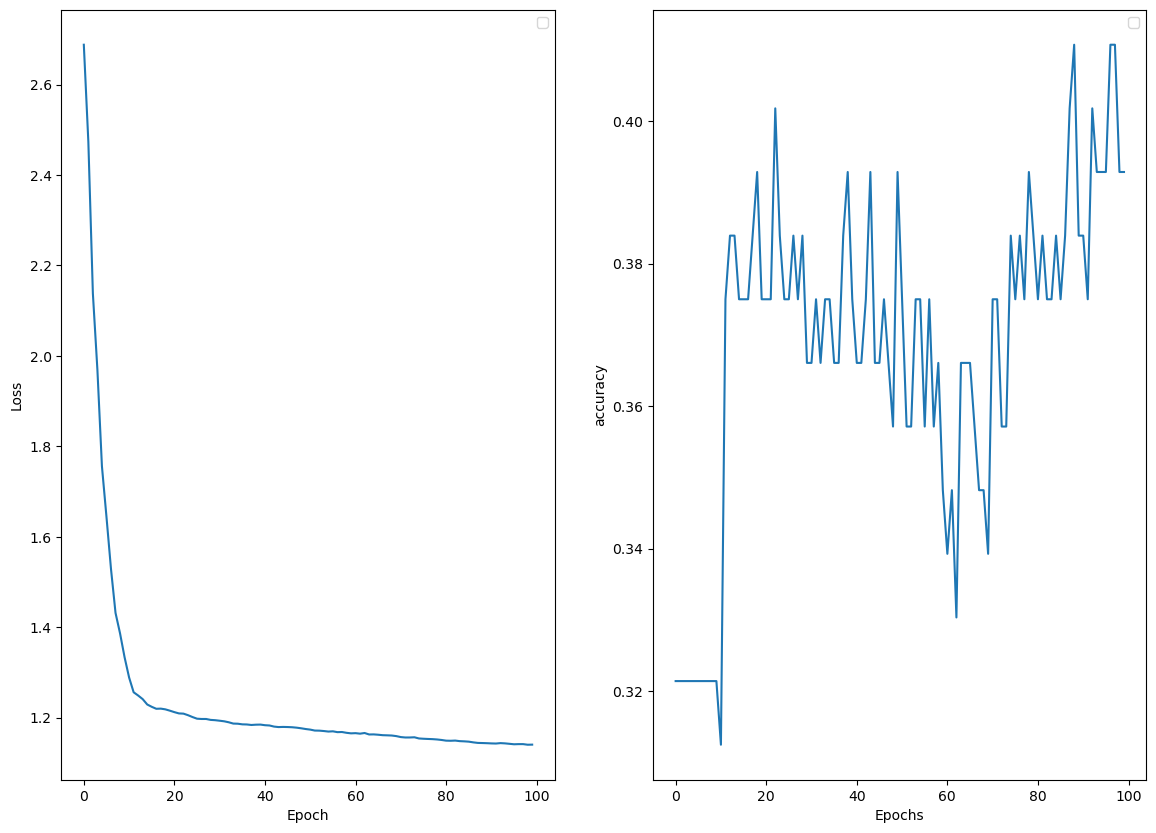

In [321]:
plt.figure(figsize=(14, 10))
plt.subplot(1, 2, 1)
plt.plot(history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()